In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

DATA_DIR = "/content/drive/MyDrive/SMAI_Assignment3/dataset_split"  # change this

if os.path.exists(DATA_DIR):
    print("✅ Dataset folder exists")
else:
    print("❌ Dataset folder NOT found")

✅ Dataset folder exists


In [5]:
# SPLIT CHECKING

# splits = ["train", "val", "test"]

# for split in splits:
#     path = os.path.join(DATA_DIR, split)

#     if not os.path.exists(path):
#         print(f"❌ {split} missing")
#         continue

#     print(f"\n📂 {split}")

#     classes = os.listdir(path)
#     print(f"Classes: {len(classes)}")

#     for cls in classes:
#         cls_path = os.path.join(path, cls)
#         if os.path.isdir(cls_path):
#             print(f"{cls}: {len(os.listdir(cls_path))} images")

#


📂 train
Classes: 12
aloo_tikki: 105 images
bhatura: 105 images
chana_masala: 105 images
daal_puri: 105 images
jalebi: 105 images
kachori: 105 images
lassi: 105 images
litti_chokha: 105 images
poha: 105 images
rabri: 105 images
kuzhi_paniyaram: 105 images
unni_appam: 105 images

📂 val
Classes: 12
aloo_tikki: 7 images
bhatura: 7 images
chana_masala: 7 images
daal_puri: 7 images
jalebi: 7 images
kachori: 7 images
lassi: 7 images
litti_chokha: 7 images
poha: 7 images
rabri: 7 images
kuzhi_paniyaram: 7 images
unni_appam: 7 images

📂 test
Classes: 12
aloo_tikki: 8 images
bhatura: 8 images
chana_masala: 8 images
daal_puri: 8 images
jalebi: 8 images
kachori: 8 images
lassi: 8 images
litti_chokha: 8 images
poha: 8 images
rabri: 8 images
kuzhi_paniyaram: 8 images
unni_appam: 8 images


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Datasets
train_dataset = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(f"{DATA_DIR}/val", transform=val_transform)
test_dataset  = datasets.ImageFolder(f"{DATA_DIR}/test", transform=val_transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['aloo_tikki', 'bhatura', 'chana_masala', 'daal_puri', 'jalebi', 'kachori', 'kuzhi_paniyaram', 'lassi', 'litti_chokha', 'poha', 'rabri', 'unni_appam']


In [7]:
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v2(pretrained=True)

# Freeze base
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[1] = nn.Linear(model.last_channel, 12)

# Train only classifier
for param in model.classifier.parameters():
    param.requires_grad = True

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 69.0MB/s]


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
for epoch in range(10):
    print(f"\n🚀 Epoch {epoch+1}/10")
    print("-" * 40)

    model.train()
    running_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 🔹 Print every 10 batches
        if batch_idx % 10 == 0:
            print(f"Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)
    print(f"\n📉 Avg Training Loss: {avg_loss:.4f}")

    # 🔹 Validation
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = correct / total
    print(f"✅ Validation Accuracy: {val_acc:.4f}")

    # 🔹 Show few predictions (debugging insight)
    import random

    print("\n🔍 Sample Predictions:")

    indices = random.sample(range(len(all_preds)), 5)

    for i in indices:
        print(f"Pred: {train_dataset.classes[all_preds[i]]} | Actual: {train_dataset.classes[all_labels[i]]}")


🚀 Epoch 1/10
----------------------------------------
Batch [0/40] | Loss: 1.6745
Batch [10/40] | Loss: 1.3973
Batch [20/40] | Loss: 1.0736
Batch [30/40] | Loss: 0.9512

📉 Avg Training Loss: 1.2369
✅ Validation Accuracy: 0.7857

🔍 Sample Predictions:
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki

🚀 Epoch 2/10
----------------------------------------
Batch [0/40] | Loss: 1.0524
Batch [10/40] | Loss: 0.7817
Batch [20/40] | Loss: 0.8475
Batch [30/40] | Loss: 0.7922

📉 Avg Training Loss: 0.7392
✅ Validation Accuracy: 0.7976

🔍 Sample Predictions:
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki
Pred: aloo_tikki | Actual: aloo_tikki

🚀 Epoch 3/10
----------------------------------------
Batch [0/40] | Loss: 0.5851
Batch [10/40] | Loss: 0.5799
Batc

In [11]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [13]:
for param in model.features[-3:].parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
torch.save(model.state_dict(), "food_model.pth")

In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.8333333333333334


In [16]:
from PIL import Image

def predict(image, model, class_names):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return class_names[pred.item()]

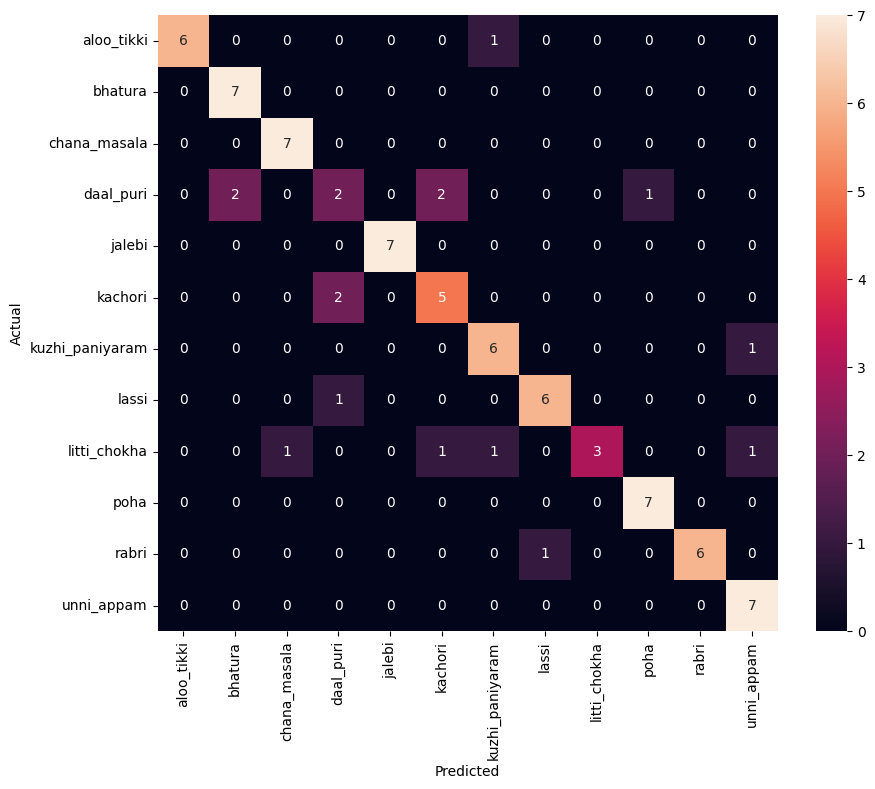

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
MODEL_PATH = "/content/drive/MyDrive/SMAI_Assignment3/food_model.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("✅ Model saved to:", MODEL_PATH)

✅ Model saved to: /content/drive/MyDrive/SMAI_Assignment3/food_model.pth


In [21]:
from torchvision import models
import torch.nn as nn
import torch

# Recreate model structure
model = models.mobilenet_v2(pretrained=False)
model.classifier[1] = nn.Linear(model.last_channel, 12)

# Load weights
MODEL_PATH = "/content/drive/MyDrive/SMAI_Assignment3/food_model.pth"
model.load_state_dict(torch.load(MODEL_PATH))

model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=